## Transcripts to Genes Annotation

## Purpose: 

In [1]:
import pandas as pd
pd.set_option('display.width', 10000000)
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import glob,os

import matplotlib.pyplot as plt
import seaborn as sns

import ptitprince

## Load Data 

In [2]:
# get all files 
files = sorted(glob.glob("../../4_bedtools_closest/outputs/*"))

# save all dataframes
tables = {}

for file in files: 
    # read gzip compressed file with tab separator
    tmp = pd.read_csv(
        file,
        compression="gzip", 
        sep="\t", 
        header=None
    )
    
    # get just the motif ID
    key = ".".join(file.split("/")[-1].split("\\")[1].split(".")[0:3])
    
    tables[key]= tmp
    

In [3]:
annotation_file = pd.read_csv(
    "../../../../inputs/mouse_transcripts_genes_mapping/mm10_genes_and_transcripts.tsv", 
    sep="\t" 
)

annotation_file = annotation_file.set_index("Transcript stable ID")

annotation_file.head()

annotation_file.index.size
annotation_file.index.unique().size

,Gene stable ID,Gene name
Transcript stable ID,,
ENSMUST00000082423,ENSMUSG00000064372,mt-Tp
ENSMUST00000082422,ENSMUSG00000064371,mt-Tt
ENSMUST00000082421,ENSMUSG00000064370,mt-Cytb
ENSMUST00000082420,ENSMUSG00000064369,mt-Te
ENSMUST00000082419,ENSMUSG00000064368,mt-Nd6


144778

144778

## Annotate Transcripts to Genes

In [4]:
# for each table 
# convert transcript ids with version to stable ids 
# set the index as the stable id 
# left join against the annotation file 
# save the new table

for key in tables:

    caller = tables[key]
    
    caller[0] = caller[0].str.split(".").str[0]
    
    caller = caller.set_index(0)
    
    caller = caller.join(annotation_file, how='left')
    
    tables[key] = caller
    

# Exploratory Analysis

In [5]:
summary_stat_df = pd.DataFrame()

## Number of Transcripts, Genes, Empty Genes

In [6]:
for key in tables:
    new_row = []
    new_row.append(key)
    new_row.append(tables[key].index.unique().size)
    new_row.append(tables[key]["Gene stable ID"].unique().size)
    new_row.append(tables[key]["Gene stable ID"].isna().sum())
    new_row.append(key.split("_")[-1])
        
    summary_stat_df = summary_stat_df.append([new_row])    

C:\Users\yragh\AppData\Local\Temp\ipykernel_13020\3525896283.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  summary_stat_df = summary_stat_df.append([new_row])
C:\Users\yragh\AppData\Local\Temp\ipykernel_13020\3525896283.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  summary_stat_df = summary_stat_df.append([new_row])
C:\Users\yragh\AppData\Local\Temp\ipykernel_13020\3525896283.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  summary_stat_df = summary_stat_df.append([new_row])
C:\Users\yragh\AppData\Local\Temp\ipykernel_13020\3525896283.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  summary_stat_df = summary_stat_df.ap

In [7]:
summary_stat_df.columns=["Sample", "Num Transcripts", "Num Genes", "Num No Annotated Genes", "Upstream Parameter"]


In [8]:
summary_stat_df["Upstream Parameter"] = summary_stat_df["Upstream Parameter"].astype("int64")

summary_stat_df.dtypes

Sample                    object
Num Transcripts            int64
Num Genes                  int64
Num No Annotated Genes     int64
Upstream Parameter         int64
dtype: object

In [9]:
summary_stat_df = summary_stat_df.sort_values(by=["Upstream Parameter"], ascending=True)

<Figure size 1200x800 with 0 Axes>

<AxesSubplot:xlabel='Upstream Parameter', ylabel='Num Transcripts'>

<Figure size 1200x800 with 0 Axes>

<AxesSubplot:xlabel='Upstream Parameter', ylabel='Num Genes'>

<Figure size 1200x800 with 0 Axes>

<AxesSubplot:xlabel='Upstream Parameter', ylabel='Num No Annotated Genes'>

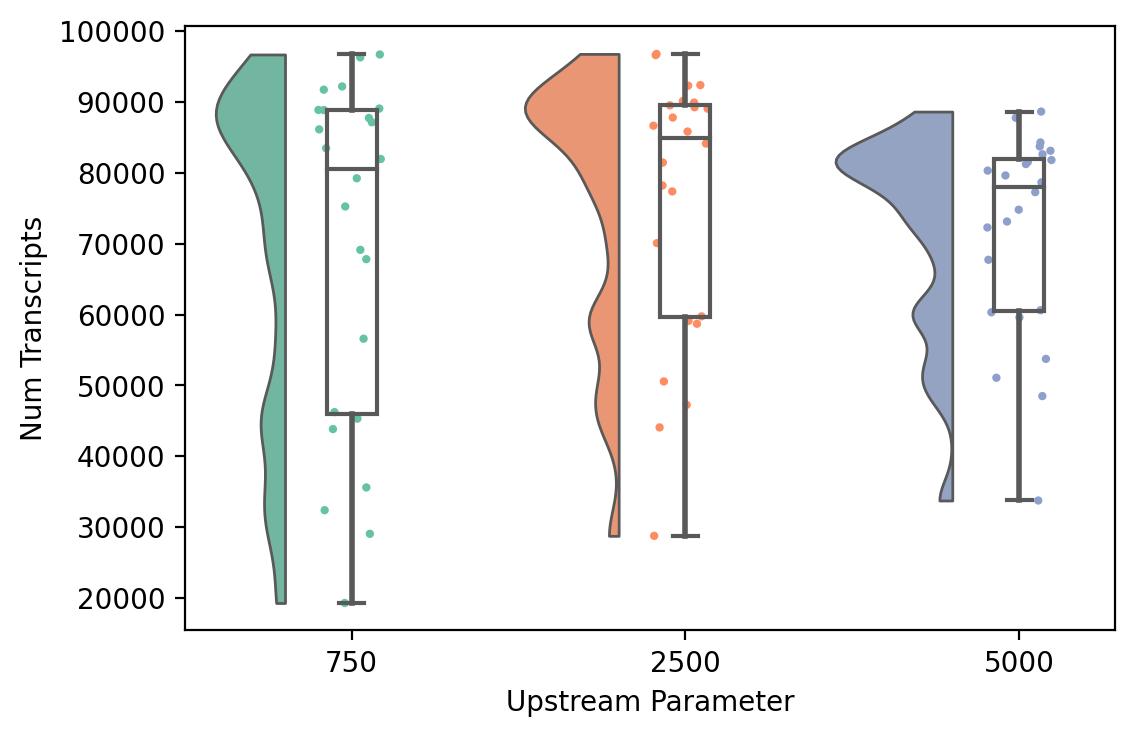

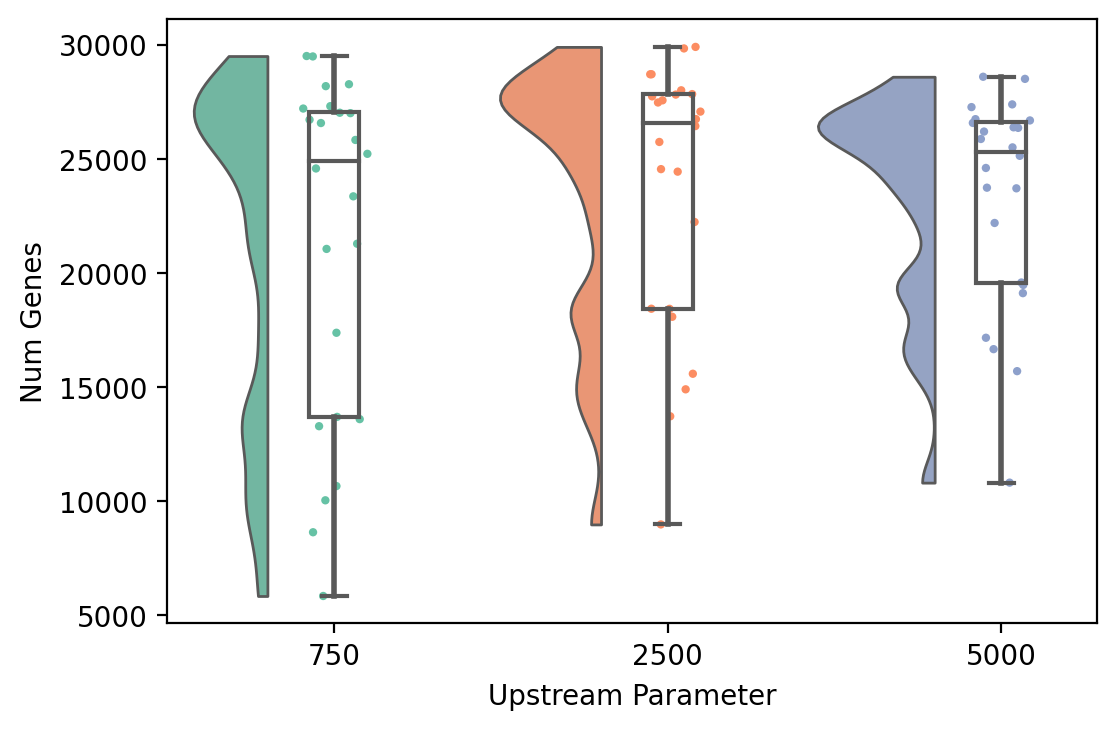

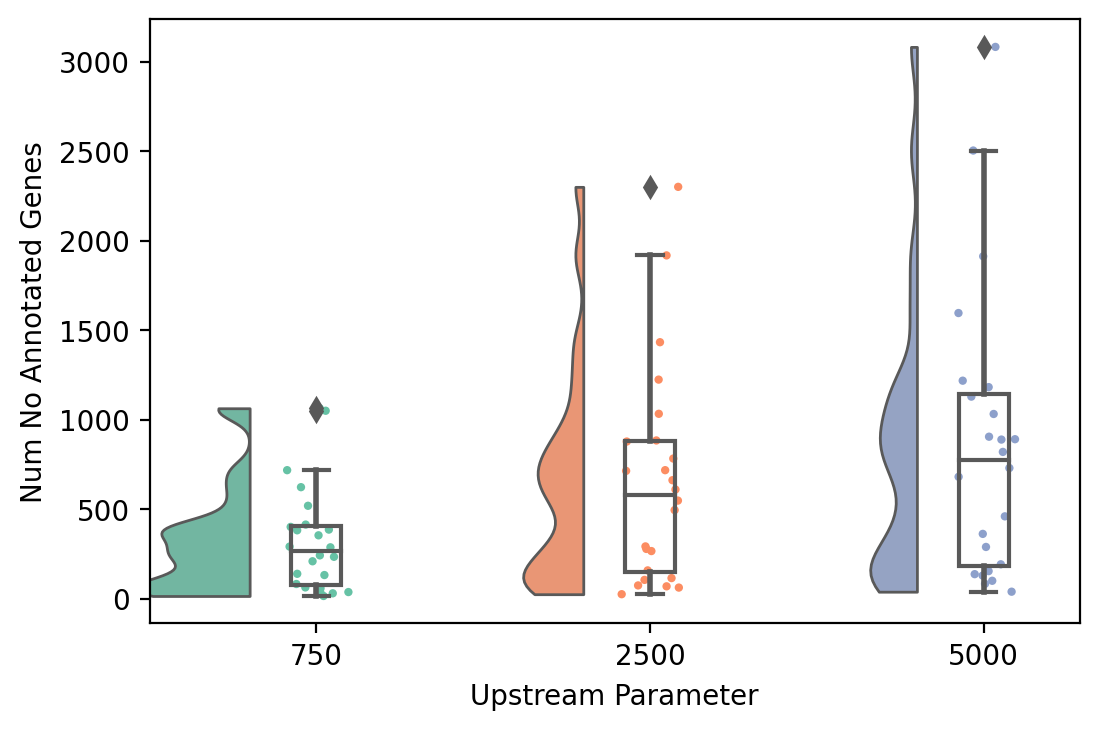

In [10]:
plot_params = ["Num Transcripts", "Num Genes", "Num No Annotated Genes"]

for param in plot_params: 
    plt.figure(dpi=200)
    ptitprince.RainCloud(x="Upstream Parameter", y=param, data=summary_stat_df)